# 005 - Backtesting Framework Examples

Comprehensive tutorial for the production backtesting module.

This notebook demonstrates:
1. **Long-only strategy** - Buy top 20% of stocks by prediction
2. **Long/short strategy** - Long top 20%, short bottom 20%
3. **Monthly vs daily rebalancing** - Performance comparison
4. **Regime-conditional strategy** - Deploy strategies based on market regime
5. **Comprehensive performance analysis** - Metrics, plots, and benchmarks

In [1]:
# %pip install seaborn  

import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.backtest import (
    Backtester,
    LongOnlyTopPct,
    LongShortTopBottom,
    RegimeConditionalStrategy,
    CashStrategy,
    plot_cumulative_returns,
    plot_drawdown,
    plot_turnover,
    plot_rolling_sharpe,
    plot_monthly_returns_heatmap,
    create_backtest_report,
    print_metrics_comparison,
)

pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print('Backtesting framework loaded successfully!')

Backtesting framework loaded successfully!


## Load Data

Load the modeling dataset with predictions from your trained model.

In [2]:
# Replace with your actual data path and data_tag
DATA_TAG = 'run_20260215_112600'  # Update this
DATA_PATH = f'../data/processed/{DATA_TAG}/modeling_dataset.parquet'

# Load data
data = pd.read_parquet(DATA_PATH)

print(f'Loaded data: {len(data):,} rows, {data["ticker"].nunique():,} tickers')
print(f'Date range: {data["date"].min()} to {data["date"].max()}')
print(f'Columns: {list(data.columns)}')

# Filter to test period (e.g., last 5 years for faster examples)
test_start = '2020-01-01'
test_data = data[data['date'] >= test_start].copy()
print(f'\nTest period: {test_data["date"].min()} to {test_data["date"].max()}')
print(f'Test data: {len(test_data):,} rows, {test_data["ticker"].nunique():,} tickers')

Loaded data: 4,086,651 rows, 1,000 tickers
Date range: 2005-01-03 00:00:00 to 2026-02-13 00:00:00
Columns: ['ticker', 'date', 'open', 'high', 'low', 'close', 'volume', 'momentum_5', 'volatility_5', 'sma_5', 'momentum_10', 'volatility_10', 'sma_10', 'momentum_20', 'volatility_20', 'sma_20', 'rsi_14', 'cumulative_return', 'running_max', 'drawdown', 'quarter_end_date', 'report_date', 'revenue', 'net_income', 'operating_income', 'gross_profit', 'ebitda', 'total_assets', 'total_equity', 'total_debt', 'total_cash', 'current_assets', 'current_liabilities', 'profit_margin', 'operating_margin', 'gross_margin', 'roe', 'roa', 'debt_to_equity', 'current_ratio', 'quick_ratio', 'revenue_growth_qoq', 'earnings_growth_qoq', 'revenue_growth_yoy', 'earnings_growth_yoy', 'sector', 'industry', 'DFF', 'DGS10', 'DGS2', 'T10Y2Y', 'CPIAUCSL', 'CPILFESL', 'PCEPI', 'GDP', 'GDPC1', 'INDPRO', 'UNRATE', 'PAYEMS', 'ICSA', 'UMCSENT', 'RSXFS', 'VIXCLS', 'DCOILWTICO', 'M2SL', 'TOTALSL', 'open_rank', 'high_rank', 'low_

## Example 1: Long-Only Strategy

Buy the top 20% of stocks by model prediction, rebalance monthly.

This is the simplest strategy - equal-weight the highest-predicted stocks.

In [ ]:
# Define strategy
strategy = LongOnlyTopPct(
    pred_col='momentum_10',  # Column name with your model predictions
    top_pct=0.20      # Top 20% of stocks
)

# Create backtester
backtester = Backtester(
    data=test_data,
    strategy=strategy,
    initial_capital=100000,
    transaction_cost_bps=10,      # 10 bps trading cost
    short_term_tax_rate=0.35,     # 35% short-term capital gains tax
    borrow_cost_annual=0.03,      # 3% annual borrow cost (for shorts)
    rebalance_frequency='monthly', # Rebalance monthly
    benchmark_ticker='SPY'         # Compare to SPY
)

# Run backtest
print('Running backtest...')
result_long = backtester.run()
print('Backtest complete!')

Running backtest...


In [4]:
# Print performance metrics
print_metrics_comparison(
    result_long.metrics,
    result_long.benchmark_metrics,
    strategy_name='Long-Only Top 20%',
    benchmark_name='SPY'
)


Metric                       Long-Only Top 20%                  SPY
Annual Return                           12.13%               14.58%
Volatility                              17.43%               17.08%
Sharpe Ratio                              0.66                 0.80
Max Drawdown                           -38.81%              -24.80%
CAGR                                    10.45%               12.95%
Calmar Ratio                              0.27                 0.52
Win Rate                                56.76%               63.51%
Avg Turnover                      19419509.20%                    -
Alpha (Annual)                          11.89%                    -
Beta                                     -0.03                    -
Information Ratio                        -0.09                    -
Tracking Error                          24.74%                    -



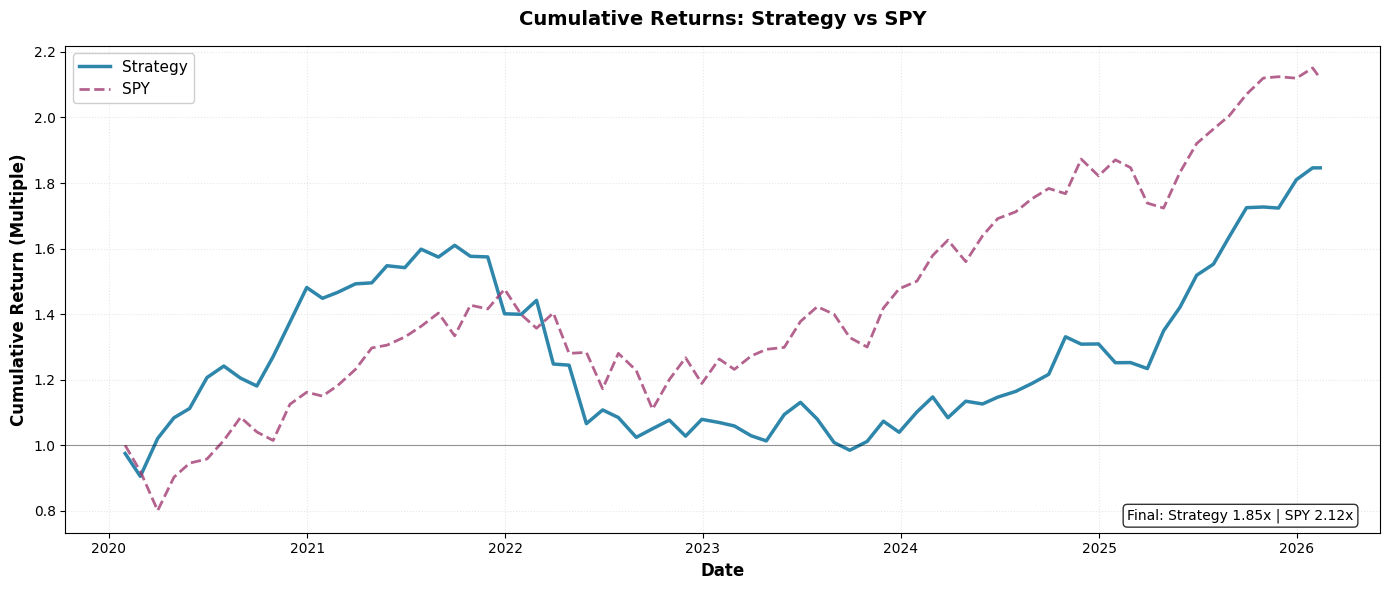

In [5]:
# Plot cumulative returns
plot_cumulative_returns(result_long, benchmark_name='SPY')
plt.show()

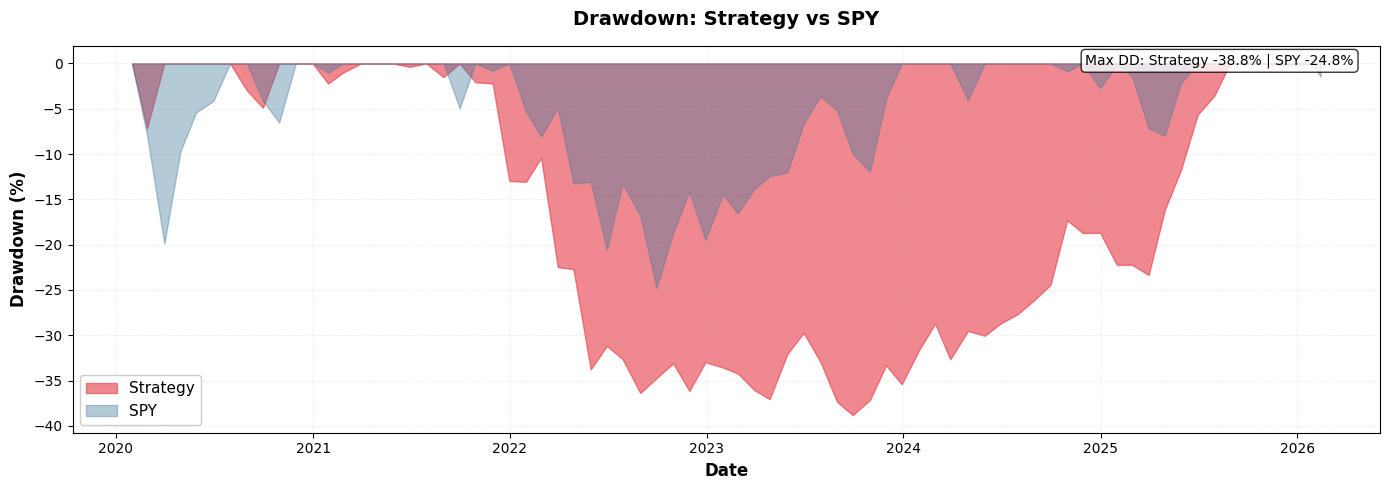

In [6]:
# Plot drawdown
plot_drawdown(result_long, benchmark_name='SPY')
plt.show()

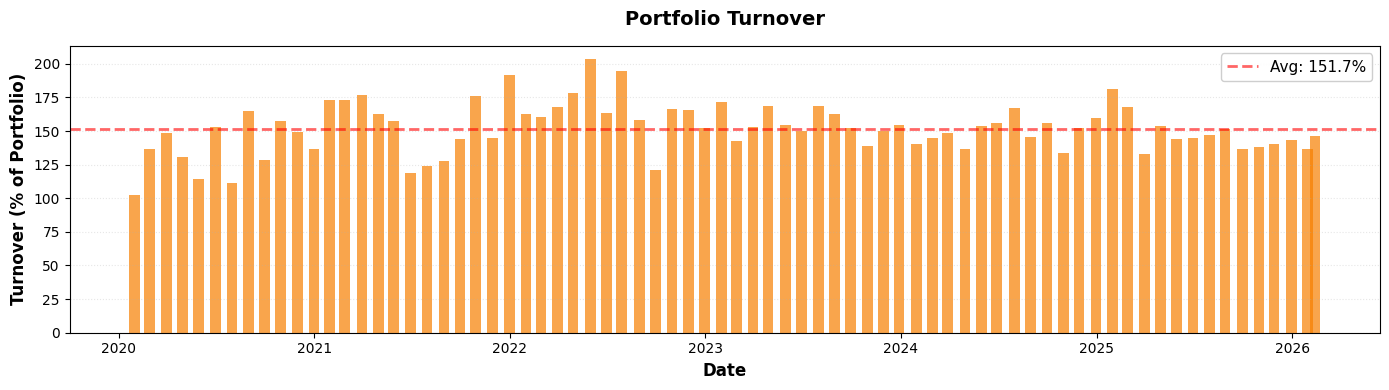

In [7]:
# Plot turnover
plot_turnover(result_long)
plt.show()

In [8]:
# Inspect positions
print('Sample positions from last rebalance:')
last_date = result_long.positions['date'].max()
last_positions = result_long.positions[result_long.positions['date'] == last_date]
print(f'\nDate: {last_date}')
print(f'Number of holdings: {len(last_positions)}')
print(f'\nTop 10 positions by value:')
last_positions.nlargest(10, 'position_value')[['ticker', 'weight', 'shares', 'price', 'position_value']]

Sample positions from last rebalance:

Date: 2026-02-13 00:00:00
Number of holdings: 200

Top 10 positions by value:


,ticker,weight,shares,price,position_value
13716,ENB,0.01,17.13,53.88,923.10
13721,BTG,0.01,170.94,5.40,923.10
13725,AEO,0.01,36.23,25.48,923.10
13737,CASY,0.01,1.39,665.86,923.10
13741,PCG,0.01,50.83,18.16,923.10
13744,LVS,0.01,16.15,57.15,923.10
13746,MPC,0.01,4.54,203.26,923.10
13747,MTZ,0.01,3.42,269.53,923.10
13749,TMUS,0.01,4.21,219.50,923.10
13763,WDC,0.01,3.28,281.58,923.10


## Example 2: Long/Short Dollar-Neutral Strategy

Long top 20%, short bottom 20%, dollar-neutral (50% long exposure, 50% short exposure).

This strategy profits from spread between winners and losers.

In [13]:
# Define long/short strategy
strategy_ls = LongShortTopBottom(
    pred_col='momentum_10',
    long_pct=0.20,        # Long top 20%
    short_pct=0.05,       # Short bottom 20%
    dollar_neutral=False   # 50% long, 50% short
)

# Create backtester
backtester_ls = Backtester(
    data=test_data,
    strategy=strategy_ls,
    initial_capital=100000,
    transaction_cost_bps=10,
    short_term_tax_rate=0.35,
    borrow_cost_annual=0.03,
    rebalance_frequency='monthly',
    benchmark_ticker='SPY'
)

# Run backtest
print('Running long/short backtest...')
result_ls = backtester_ls.run()
print('Backtest complete!')

Running long/short backtest...
Backtest complete!


In [ ]:
# Print performance metrics
print_metrics_comparison(
    result_ls.metrics,
    result_ls.benchmark_metrics,
    strategy_name='Long/Short (20/5)',
    benchmark_name='SPY'
)


Metric                      Long/Short (20/20)                  SPY
Annual Return                         -100.00%               14.58%
Volatility                              36.23%               17.08%
Sharpe Ratio                            -21.90                 0.80
Max Drawdown                          -100.03%              -24.80%
CAGR                                  -100.00%               12.95%
Calmar Ratio                             -1.00                 0.52
Win Rate                                 0.00%               63.51%
Avg Turnover                        267551.96%                    -
Alpha (Annual)                        -794.62%                    -
Beta                                      0.10                    -
Information Ratio                       -20.54                    -
Tracking Error                          39.28%                    -



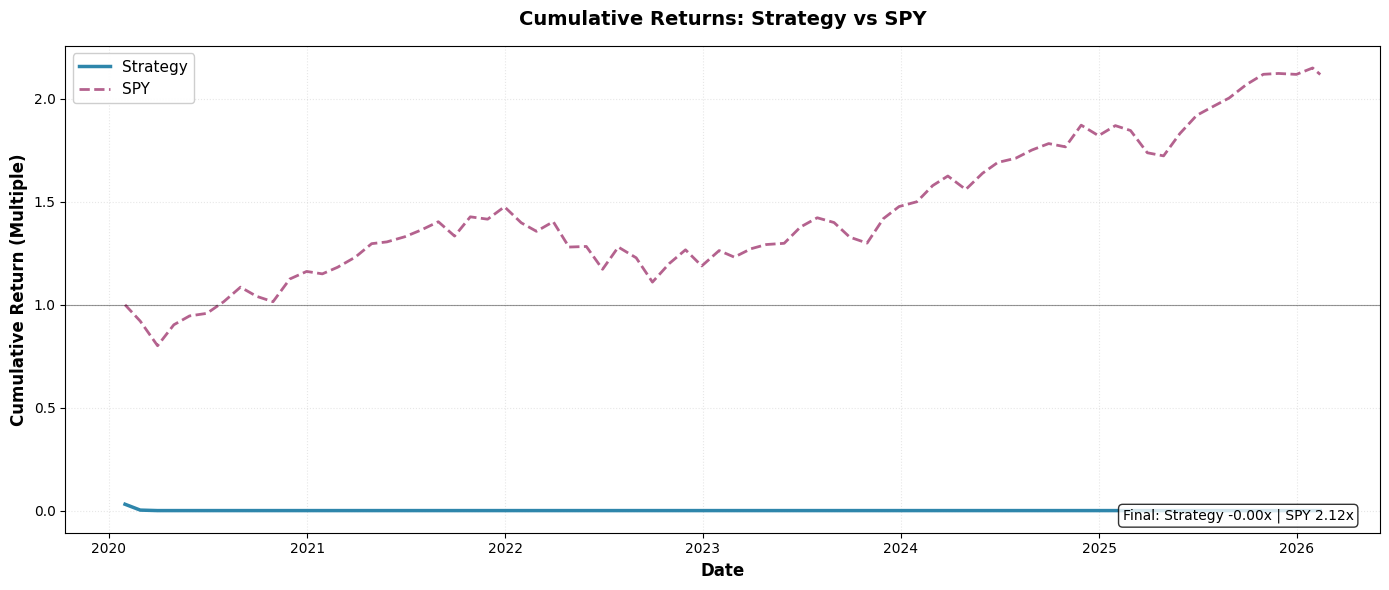

In [12]:
# Plot cumulative returns
plot_cumulative_returns(result_ls, benchmark_name='SPY')
plt.show()

In [ ]:
# Compare long-only vs long/short
fig, ax = plt.subplots(figsize=(14, 6))

cum_long = (1 + result_long.returns).cumprod()
cum_ls = (1 + result_ls.returns).cumprod()
cum_spy = (1 + result_long.benchmark_returns).cumprod()

ax.plot(cum_long.index, cum_long.values, label='Long-Only Top 20%', linewidth=2.5, color='#2E86AB')
ax.plot(cum_ls.index, cum_ls.values, label='Long/Short (20/20)', linewidth=2.5, color='#E63946')
ax.plot(cum_spy.index, cum_spy.values, label='SPY', linewidth=2, linestyle='--', color='#A23B72', alpha=0.7)

ax.set_ylabel('Cumulative Return', fontsize=12, fontweight='bold')
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_title('Strategy Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, linestyle=':')
ax.axhline(y=1.0, color='black', linestyle='-', linewidth=0.8, alpha=0.4)
plt.tight_layout()
plt.show()

## Example 3: Monthly vs Daily Rebalancing

Compare monthly and daily rebalancing for the same strategy.

Daily rebalancing typically increases turnover and costs but may improve returns.

In [ ]:
# Monthly rebalancing (already have result_long from Example 1)

# Daily rebalancing
strategy_daily = LongOnlyTopPct(pred_col='pred', top_pct=0.20)

backtester_daily = Backtester(
    data=test_data,
    strategy=strategy_daily,
    initial_capital=100000,
    transaction_cost_bps=10,
    short_term_tax_rate=0.35,
    rebalance_frequency='daily',  # Daily rebalancing
    benchmark_ticker='SPY'
)

print('Running daily rebalancing backtest...')
result_daily = backtester_daily.run()
print('Backtest complete!')

In [ ]:
# Compare metrics
print('\n' + '='*70)
print('MONTHLY REBALANCING')
print('='*70)
print_metrics_comparison(
    result_long.metrics,
    result_long.benchmark_metrics,
    strategy_name='Long-Only (Monthly)',
    benchmark_name='SPY'
)

print('\n' + '='*70)
print('DAILY REBALANCING')
print('='*70)
print_metrics_comparison(
    result_daily.metrics,
    result_daily.benchmark_metrics,
    strategy_name='Long-Only (Daily)',
    benchmark_name='SPY'
)

In [ ]:
# Compare turnover
print(f'Average monthly turnover: {result_long.metrics["avg_turnover"]:.2%}')
print(f'Average daily turnover: {result_daily.metrics["avg_turnover"]:.2%}')

## Example 4: Regime-Conditional Strategy

Deploy different strategies based on market regime predictions.

**Note**: This requires a `regime_pred` column in your data. If you don't have regime predictions, skip this section or create dummy regime data for illustration.

In [ ]:
# Check if regime predictions exist
if 'regime_pred' in test_data.columns:
    print('Regime predictions found!')
    print(f'Regime distribution:')
    print(test_data['regime_pred'].value_counts().sort_index())
    has_regime = True
else:
    print('No regime predictions found. Creating dummy regime data for illustration...')
    # Create dummy regime based on SPY returns (simple example)
    spy_data = test_data[test_data['ticker'] == 'SPY'][['date', 'close']].copy()
    spy_data['spy_return'] = spy_data['close'].pct_change(20)  # 20-day return
    spy_data['regime_pred'] = pd.cut(
        spy_data['spy_return'],
        bins=[-np.inf, -0.05, 0.05, np.inf],
        labels=[0, 1, 2]  # 0=bear, 1=neutral, 2=bull
    ).astype(float)
    
    # Merge back to main data
    test_data = test_data.merge(
        spy_data[['date', 'regime_pred']],
        on='date',
        how='left'
    )
    test_data['regime_pred'] = test_data['regime_pred'].fillna(1)  # Default to neutral
    
    print('Dummy regime distribution:')
    print(test_data.groupby('date')['regime_pred'].first().value_counts().sort_index())
    has_regime = True

In [ ]:
if has_regime:
    # Define regime-specific strategies
    regime_strategies = {
        0: CashStrategy(),                      # Bear market (regime 0): Hold cash
        1: LongOnlyTopPct(top_pct=0.30),        # Neutral market (regime 1): Long top 30%
        2: LongShortTopBottom(long_pct=0.20, short_pct=0.20)  # Bull market (regime 2): Long/short
    }
    
    strategy_regime = RegimeConditionalStrategy(
        regime_col='regime_pred',
        regime_strategies=regime_strategies
    )
    
    # Create backtester
    backtester_regime = Backtester(
        data=test_data,
        strategy=strategy_regime,
        initial_capital=100000,
        transaction_cost_bps=10,
        short_term_tax_rate=0.35,
        borrow_cost_annual=0.03,
        rebalance_frequency='monthly',
        benchmark_ticker='SPY'
    )
    
    print('Running regime-conditional backtest...')
    result_regime = backtester_regime.run()
    print('Backtest complete!')
    
    # Print metrics
    print_metrics_comparison(
        result_regime.metrics,
        result_regime.benchmark_metrics,
        strategy_name='Regime-Conditional',
        benchmark_name='SPY'
    )
    
    # Plot
    plot_cumulative_returns(result_regime, benchmark_name='SPY')
    plt.show()
else:
    print('Skipping regime-conditional example (no regime data)')

## Example 5: Comprehensive Backtest Report

Generate a full multi-panel report with all plots and metrics.

In [ ]:
# Create comprehensive report
fig = create_backtest_report(
    result_long,
    benchmark_name='SPY',
    strategy_name='Long-Only Top 20%',
    save_path='../backtest_report_long_only.png'  # Optional: save to file
)
plt.show()

In [ ]:
# Create report for long/short strategy
fig = create_backtest_report(
    result_ls,
    benchmark_name='SPY',
    strategy_name='Long/Short (20/20)',
    save_path='../backtest_report_long_short.png'
)
plt.show()

## Advanced: Custom Strategy

Example of creating a custom strategy by subclassing `Strategy`.

In [ ]:
from src.backtest import Strategy

class WeightedTopPct(Strategy):
    """
    Custom strategy: Weight stocks by prediction score (not equal-weight).
    
    Higher predictions get higher weights.
    """
    
    def __init__(self, pred_col: str = 'pred', top_pct: float = 0.20):
        self.pred_col = pred_col
        self.top_pct = top_pct
    
    def select(self, data: pd.DataFrame, date: pd.Timestamp) -> dict:
        # Filter to this date
        day_data = data[data['date'] == date].copy()
        
        if day_data.empty or self.pred_col not in day_data.columns:
            return {}
        
        # Remove missing predictions
        day_data = day_data.dropna(subset=[self.pred_col])
        
        if len(day_data) == 0:
            return {}
        
        # Get top percentile
        cutoff = day_data[self.pred_col].quantile(1 - self.top_pct)
        selected = day_data[day_data[self.pred_col] >= cutoff].copy()
        
        if len(selected) == 0:
            return {}
        
        # Weight by prediction score (normalized to sum to 1.0)
        selected['raw_weight'] = selected[self.pred_col] - selected[self.pred_col].min() + 1e-6
        total_weight = selected['raw_weight'].sum()
        selected['weight'] = selected['raw_weight'] / total_weight
        
        return dict(zip(selected['ticker'], selected['weight']))

# Test custom strategy
custom_strategy = WeightedTopPct(pred_col='pred', top_pct=0.20)

backtester_custom = Backtester(
    data=test_data,
    strategy=custom_strategy,
    initial_capital=100000,
    transaction_cost_bps=10,
    short_term_tax_rate=0.35,
    rebalance_frequency='monthly',
    benchmark_ticker='SPY'
)

print('Running custom strategy backtest...')
result_custom = backtester_custom.run()
print('Backtest complete!')

print_metrics_comparison(
    result_custom.metrics,
    result_custom.benchmark_metrics,
    strategy_name='Weighted Top 20%',
    benchmark_name='SPY'
)

## Summary

This notebook demonstrated the full capabilities of the backtesting framework:

1. **Long-only strategies** - Simple and effective for trending markets
2. **Long/short strategies** - Market-neutral approaches that profit from spreads
3. **Rebalancing frequency** - Monthly vs daily trade-offs
4. **Regime-conditional strategies** - Adapt to market conditions
5. **Custom strategies** - Easy extensibility via Strategy ABC
6. **Comprehensive reporting** - Professional plots and metrics

### Key Takeaways:

- The framework handles realistic costs (transaction costs, taxes, borrow fees)
- Strategies are composable and extensible
- Benchmark comparison is automatic (SPY/QQQ)
- Supports both monthly and daily rebalancing
- Publication-quality visualizations included

### Next Steps:

1. Run backtests on your full modeling dataset
2. Experiment with different strategies and parameters
3. Analyze which regimes your model performs best in
4. Optimize top_pct parameter (10%, 20%, 30%, etc.)
5. Compare different prediction columns if you have multiple models